# PAIMANA Model 2 — Time (Schedule) Overrun Prediction
Predicts `schedule_slippage_months` (revised completion date minus original completion date, in months), using only pre-revision project attributes.

## 0. Setup
Load the PAIMANA CSV and collapse to one row per project (latest monthly report).

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import xgboost as xgb
import joblib

RANDOM_STATE = 42
DATA_PATH = "../Datasets/PAIMANA_all_13_reports_project_level_37_features_complete.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "../Paimana.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
df["report_month"] = pd.to_datetime(df["report_month"], format="%Y-%m")
df = df.sort_values("report_month").groupby("project_code", as_index=False).tail(1).reset_index(drop=True)
print(f"Projects (latest snapshot each): {len(df)}")
df.head()


Projects (latest snapshot each): 3394


,report_month,ministry,sector,sl_no,project_name,implementing_agency,project_code,legacy_ocms_code,pmgid,state,...,schedule_slippage_months,completion_date_revised_flag,monthly_progress_change_pct,monthly_expenditure_change_cr,monthly_revised_cost_change_cr,monthly_cost_growth_pct,progress_velocity_pct_per_month,expenditure_growth_pct,required_progress_velocity_pct_per_month,velocity_gap_pct_points
0,2025-07-01,Ministry of Petroleum & Natural Gas,Oil & Gas,426,71 MWp [DC] Solar power project at Prayagraj,Bharat Petroleum Corporation Limited [BPCL],709801,NaN,NaN,Uttar Pradesh,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-07-01,Ministry of Petroleum & Natural Gas,Oil & Gas,420,City Gas Distribution Project at Dharmapuri an...,MinistryofPetroleumNaturalGas,709768,NaN,NaN,Tamil Nadu,...,0.00,0,NaN,NaN,NaN,NaN,NaN,NaN,1.461089,NaN
2,2025-07-01,Ministry of Railways,Railways,471,New B.G. Railway Line- Araria to Galgalia [Tha...,Northeast Frontier Railway [NFR],705400,NaN,NaN,Bihar,...,6.97,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-07-01,Ministry of Railways,Railways,461,AGTHORI KAMAKHYA SECTION WITH CONSTRUCTION OF ...,Northeast Frontier Railway [NFR],613788,NaN,NaN,Assam,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-07-01,Ministry of Railways,Railways,466,Sakri-Hasanpur Road New Rail Line Project,East Central Railway [ECR] - I,705363,NaN,NaN,Bihar,...,2.96,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Feature engineering (leakage-free)

We deliberately **exclude** any column that is only populated *after* a project has already
been revised — `revised_cost_cr`, `cost_revision_ratio`, `expenditure_revised_cost_pct`,
`monthly_revised_cost_change_cr`, `monthly_cost_growth_pct`, `remaining_duration_months`,
`required_progress_velocity_pct_per_month`, `velocity_gap_pct_points`,
`completion_date_revised_flag`, `schedule_slippage_months`.

Training on those would let the model see the answer. Instead we use only "as-of-now"
attributes available for *any* project, revised or not.

In [2]:
# 1. Base cleanups
df["schedule_slippage_months"] = df["schedule_slippage_months"].fillna(0)  # no revision yet -> 0 slippage so far
df["cost_overrun_pct"] = df["cost_overrun_pct"].fillna(0)

# Frequency encodings
freq_state = df["state"].value_counts(normalize=True)
freq_agency = df["implementing_agency"].value_counts(normalize=True)
df["state_freq"] = df["state"].map(freq_state).fillna(0)
df["agency_freq"] = df["implementing_agency"].map(freq_agency).fillna(0)

# --- Enhanced Domain Feature Engineering (v3) ---
df["age_to_planned_ratio"] = (df["project_age_months"] / (df["planned_duration_months"] + 1)).clip(-5, 20)
df["burn_rate_ratio"] = (df["expenditure_original_cost_pct"] / (df["physical_progress_pct"] + 1)).clip(-5, 50)
df["is_mega_project"] = (df["original_cost_cr"] >= 1000).astype(float)
df["log_orig_cost"] = np.log1p(df["original_cost_cr"].clip(lower=0))
df["log_expenditure"] = np.log1p(df["cumulative_expenditure_cr"].clip(lower=0))
df["remaining_work_rate"] = (df["remaining_progress_pct"] / (df["remaining_duration_months"].clip(lower=1) + 1)).clip(0, 100)
df["has_cost_overrun"] = (df["cost_overrun_pct"] > 0).astype(float)

NUMERIC_FEATURES = [
    "original_cost_cr", "cumulative_expenditure_cr", "physical_progress_pct",
    "expenditure_original_cost_pct", "project_age_months", "planned_duration_months",
    "monthly_progress_change_pct", "monthly_expenditure_change_cr",
    "progress_velocity_pct_per_month", "expenditure_growth_pct",
    "progress_expenditure_gap_pct", "remaining_progress_pct",
    "state_freq", "agency_freq",
    "age_to_planned_ratio", "burn_rate_ratio", "is_mega_project",
    "log_orig_cost", "log_expenditure", "remaining_work_rate",
    "has_cost_overrun", "cost_overrun_pct"
]
CATEGORICAL_FEATURES = ["ministry", "sector"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

for c in CATEGORICAL_FEATURES:
    df[c] = df[c].fillna("Unknown")

X = df[FEATURES].copy()
X = X.replace([np.inf, -np.inf], np.nan)

preprocess = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", "passthrough", NUMERIC_FEATURES),
])

# --- Improved Model Architecture ---
# Tuned XGBoost with L1/L2 regularization and tree subsampling to prevent overfitting
def build_model():
    return Pipeline([
        ("prep", preprocess),
        ("model", xgb.XGBRegressor(
            n_estimators=400, max_depth=5, learning_rate=0.035, subsample=0.85,
            colsample_bytree=0.8, reg_lambda=3.0, reg_alpha=0.5,
            random_state=RANDOM_STATE, n_jobs=-1)),
    ])

def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    print(f"[{name}]  R2={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}")
    return {"r2": r2, "mae": mae, "rmse": rmse}


## 2. Train / test split + model

In [4]:
y_time = df["schedule_slippage_months"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y_time, test_size=0.2, random_state=RANDOM_STATE)

m_time = build_model().fit(X_tr, y_tr)
pred = m_time.predict(X_te)
metrics_time = evaluate("Schedule Slippage (months, test)", y_te, pred)

train_pred = m_time.predict(X_tr)
test_pred = m_time.predict(X_te)   

train_r2 = r2_score(y_tr, train_pred)
test_r2 = r2_score(y_te, test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

[Schedule Slippage (months, test)]  R2=0.942  MAE=3.22  RMSE=6.34
Train R2: 0.9893
Test R2: 0.9424
Gap (train - test): 0.0469


## 3. Feature importance (permutation importance on test set)

In [5]:
imp = permutation_importance(m_time, X_te, y_te, n_repeats=8, random_state=RANDOM_STATE, scoring="r2", n_jobs=-1)
imp_series = pd.Series(imp.importances_mean, index=X.columns).sort_values(ascending=False)
imp_series.head(10)

project_age_months               2.719742
planned_duration_months          1.459701
physical_progress_pct            0.028919
original_cost_cr                 0.011571
ministry                         0.006727
progress_expenditure_gap_pct     0.003481
expenditure_original_cost_pct    0.003336
state_freq                       0.002787
agency_freq                      0.002423
remaining_progress_pct           0.002253
dtype: float64

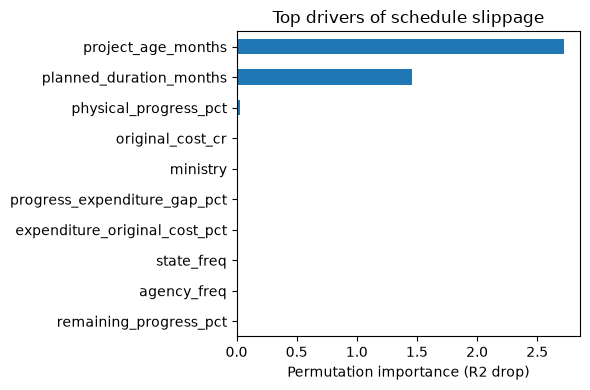

In [6]:
import matplotlib.pyplot as plt
imp_series.head(10).sort_values().plot(kind="barh", figsize=(6,4), title="Top drivers of schedule slippage")
plt.xlabel("Permutation importance (R2 drop)")
plt.tight_layout()
plt.show()

## 4. Inspect predictions

In [7]:
pred_df = pd.DataFrame({
    "project_name": df.loc[X_te.index, "project_name"],
    "actual_slippage_months": y_te,
    "predicted_slippage_months": pred,
}).sort_values("actual_slippage_months", ascending=False)
pred_df.head(15)

,project_name,actual_slippage_months,predicted_slippage_months
1456,Start of Karur Bypass - Dindigul from km. 292....,210.00,140.610016
2860,Subansiri Lower HE Project [2000 MW],197.95,167.131178
2666,Kochi - Koottanad - Bangalore - Mangalore Pipe...,164.99,178.651370
1110,Chhapra - Hajipur from km. 143.200 to km. 209....,153.00,148.339873
1286,Rayadurg-Tumkur via Kalyandurg New Line [207 k...,149.03,163.819851
1427,6L of Bhubaneswar - Jagatpur - Chandikhole Sec...,142.98,129.079816
2342,Barwa Adda Km. 398.240 to Panagarh Km. 521.120,118.97,110.443669
2689,Multi Product Pipeline from Irugur to Devangonthi,114.96,120.392794
1563,Sheohar-Sitamarhi Section km 40.000 to 79.400 ...,100.04,63.885079
1268,Dholpur - Sirmuttra Gauge Conversion (North Ce...,96.00,153.604341


## 5. Save model

In [8]:
os.makedirs("../Models", exist_ok=True)
joblib.dump(m_time, "../Models/model_time_overrun.joblib")
print("saved model_time_overrun.joblib")


saved model_time_overrun.joblib
